
# Tarea 1: Demographic Profile & Migration Landscape
---

**Points**: 10\
**Released**: Thursday, March 12, 2026\
**Due**: Thursday, March 26, 2026 (before class)\
**submission**: Canvas -- PDF export of your notebook + link to your Github repo

---
## Goal

Build a demographic and migration portrait of your assigned comunas
using the Census 2024 microdata.  In Tarea 0 you proved you could
open and inspect each dataset.  Now you go deeper into the Census:
joining tables, computing indicators, building visualizations, and
producing a **comuna-level summary table** that you will reuse in
Tarea 3.

By the end of this assignment you should be comfortable with:

- Joining hierarchical tables (vivienda, hogar, persona) on their
  linking keys
- Computing demographic indicators (age distributions, dependency
  ratios, education, employment)
- Working with migration variables in the Census
- Building age pyramids and choropleth maps
- Comparing your comunas to national or regional averages

---

**Students**: Jose Pino & Javier Becerra.\
**Group**: 1\
**Comunas**: La Granja (116,571) + Macul (116,534) + San Ramón (94,906) = 328,011

---

## Part 0: Data Loading & Joins (2 pts)

### 0.1 Load the three Census tables

Load `viviendas_censo2024.parquet`, `hogares_censo2024.parquet`, and
`personas_censo2024.parquet`.  For each table, select only the
columns you will need (see below).  **Do not load every column.**

Suggested columns:

- **vivienda**: `id_vivienda`, `region`, `codigo_comuna`,
  `nombre_comuna`, `materialidad`
- **hogar**: `id_vivienda`, `id_hogar`, `hacinamiento`, `tenencia`
- **persona**: `id_vivienda`, `id_hogar`, `id_persona`, `sexo`,
  `edad`, `p27_nacionalidad`, `p27_nacionalidad_rec`,
  `p24_lug_resid5`, `p25_lug_nacimiento`, `p26_llegada_periodo`,
  `escolaridad`, `cine11`, `sit_fuerza_trabajo`,
  `cod_ciuo`, `cod_caenes`, `p45_medio_transporte`

In [1]:
import pandas as pd #importamos la librería pandas para trabajar con DataFrames

# --- Importamos Personas ---
persona = pd.read_parquet( #leemos el archivo parquet con las columnas especificadas
"D:/Cosas javier/Cosas/Clases/6 - 1° trimestre/Preparación y analisis de datos/Datasets/personas_censo2024.parquet", #nombre del archivo
columns=["id_vivienda", "id_hogar", "id_persona", "sexo", "edad", "p27_nacionalidad", "p27_nacionalidad_rec", "p27_nacionalidad_esp" ,"p24_lug_resid5", "p25_lug_nacimiento", "p25_lug_nacimiento_rec", "p26_llegada_periodo", "escolaridad", "cine11", "sit_fuerza_trabajo", "cod_ciuo", "cod_caenes", "p45_medio_transporte"]
)
print(f"Total personas: {len(persona):,}") #cantidad total de personas en el DataFrame
print(persona.dtypes) #tipos de datos de cada columna

#---- Importamos Hogares ----
hogar = pd.read_parquet( #leemos el archivo parquet con las columnas especificadas
"D:/Cosas javier/Cosas/Clases/6 - 1° trimestre/Preparación y analisis de datos/Datasets/hogares_censo2024.parquet", #nombre del archivo
columns=["id_vivienda", "id_hogar", "tipologia_hogar", "p12_tenencia_viv"]
)
print(f"Total hogares: {len(hogar):,}") #cantidad total de hogares en el DataFrame
print(hogar.dtypes) #tipos de datos de cada columna

#---- Importamos Viviendas ----
vivienda = pd.read_parquet( #leemos el archivo parquet con las columnas especificadas
"D:/Cosas javier/Cosas/Clases/6 - 1° trimestre/Preparación y analisis de datos/Datasets/viviendas_censo2024.parquet", #nombre del archivo
columns=["id_vivienda", "region", "comuna", "p4a_mat_paredes", "p4b_mat_techo"]
)
print(f"Total viviendas: {len(vivienda):,}") #cantidad total de viviendas en el DataFrame
print(vivienda.dtypes) #tipos de datos de cada columna

Total personas: 18,480,432
id_vivienda                 int32
id_hogar                    int32
id_persona                  int32
sexo                        int32
edad                        int32
p27_nacionalidad            int32
p27_nacionalidad_rec        int32
p27_nacionalidad_esp        int32
p24_lug_resid5              int32
p25_lug_nacimiento          int32
p25_lug_nacimiento_rec      int32
p26_llegada_periodo       float64
escolaridad                 int32
cine11                      int32
sit_fuerza_trabajo        float64
cod_ciuo                  float64
cod_caenes                    str
p45_medio_transporte      float64
dtype: object
Total hogares: 6,622,597
id_vivienda           int32
id_hogar              int32
tipologia_hogar     float64
p12_tenencia_viv    float64
dtype: object
Total viviendas: 7,664,466
id_vivienda          int32
region               int32
comuna               int32
p4a_mat_paredes    float64
p4b_mat_techo      float64
dtype: object


### 0.2 Filter to your comunas
---

Filter the **vivienda** table to your assigned comunas using
`codigo_comuna`.  Then use this filtered set to drive the joins:

In [2]:
### 0.2 Filter to your comunas
MY_COMUNAS = [13111, 13118, 13131] # lista de comunas asignadas
viv = vivienda[vivienda["comuna"].isin(MY_COMUNAS)] # filtramos el DataFrame de viviendas para quedarnos solo con las filas donde la comuna esté en la lista de comunas asignadas
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])] # filtramos el DataFrame de hogares para quedarnos solo con las filas donde el id_vivienda esté en el DataFrame de viviendas filtrado
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])] # filtramos el DataFrame de personas para quedarnos solo con las filas donde el id_vivienda esté en el DataFrame de viviendas filtrado

Report the number of rows in each filtered table.

In [3]:
# Number of rows in each table after filtering
print(f"Viviendas: {len(viv):,}")
print(f"Hogares: {len(hog):,}")
print(f"Personas: {len(per):,}")

Viviendas: 111,482
Hogares: 109,926
Personas: 311,824


### 0.3 Join the tables
---
Join persona to hogar on `[id_vivienda, id_hogar]`, then join the
result to vivienda on `id_vivienda`.  Verify that the number of rows
after joining equals the number of persona rows (a left join should
not add or lose rows here).

In [4]:
### 0.3 Join the tables
df = per.merge(hog, on=["id_vivienda", "id_hogar"], how="left") \
        .merge(viv, on="id_vivienda", how="left") # realizamos la unión de los DataFrames utilizando el método merge de pandas, primero unimos el DataFrame de personas con el de hogares utilizando las columnas id_vivienda e id_hogar como claves de unión, y luego unimos el resultado con el DataFrame de viviendas utilizando la columna id_vivienda como clave de unión. El tipo de unión utilizado es "left", lo que significa que se mantendrán todas las filas del DataFrame de personas y se agregarán las columnas correspondientes de los otros DataFrames donde haya coincidencias en las claves de unión.
assert len(df) == len(per), "Row count mismatch after join!" # verificamos que el número de filas después de la unión sea igual al número de filas en el DataFrame de personas, lo que indica que no se han agregado ni perdido filas durante la unión.


Report `df.shape` and `df.info()`.

In [5]:
# reportamos la forma del DataFrame resultante y su información general
print(df.shape) # imprimimos la forma del DataFrame resultante, que muestra el número
# de filas y columnas
print(df.info()) # imprimimos la información general del DataFrame resultante, que incluye el
# número de entradas, el número de columnas, los nombres de las columnas, el tipo de datos de cada columna y la cantidad de valores no nulos en cada columna

(311824, 24)
<class 'pandas.DataFrame'>
RangeIndex: 311824 entries, 0 to 311823
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_vivienda             311824 non-null  int32  
 1   id_hogar                311824 non-null  int32  
 2   id_persona              311824 non-null  int32  
 3   sexo                    311824 non-null  int32  
 4   edad                    311824 non-null  int32  
 5   p27_nacionalidad        311824 non-null  int32  
 6   p27_nacionalidad_rec    311824 non-null  int32  
 7   p27_nacionalidad_esp    311824 non-null  int32  
 8   p24_lug_resid5          311824 non-null  int32  
 9   p25_lug_nacimiento      311824 non-null  int32  
 10  p25_lug_nacimiento_rec  311824 non-null  int32  
 11  p26_llegada_periodo     33261 non-null   float64
 12  escolaridad             311824 non-null  int32  
 13  cine11                  311824 non-null  int32  
 14  sit_fuerza_trabajo

---

## Part 1: Demographic Profile (3 pts)

### 1.1 Age pyramid by sex (1 pt)


Create a population pyramid (horizontal bar chart) for your comunas
combined, with 5-year age bins (`0-4`, `5-9`, ..., `80+`).  Males
should extend to the left, females to the right.

Use `pd.cut()` to create age bins:

**Overlay**: on the same pyramid (or side-by-side), distinguish
**Chilean-born** vs. **foreign-born** residents using
`p25_lug_nacimiento_rec `.  Use different colors or hatching so the
reader can see the immigrant age structure at a glance.

Remember: `-99` in `edad` means missing.  Filter those out before
plotting.

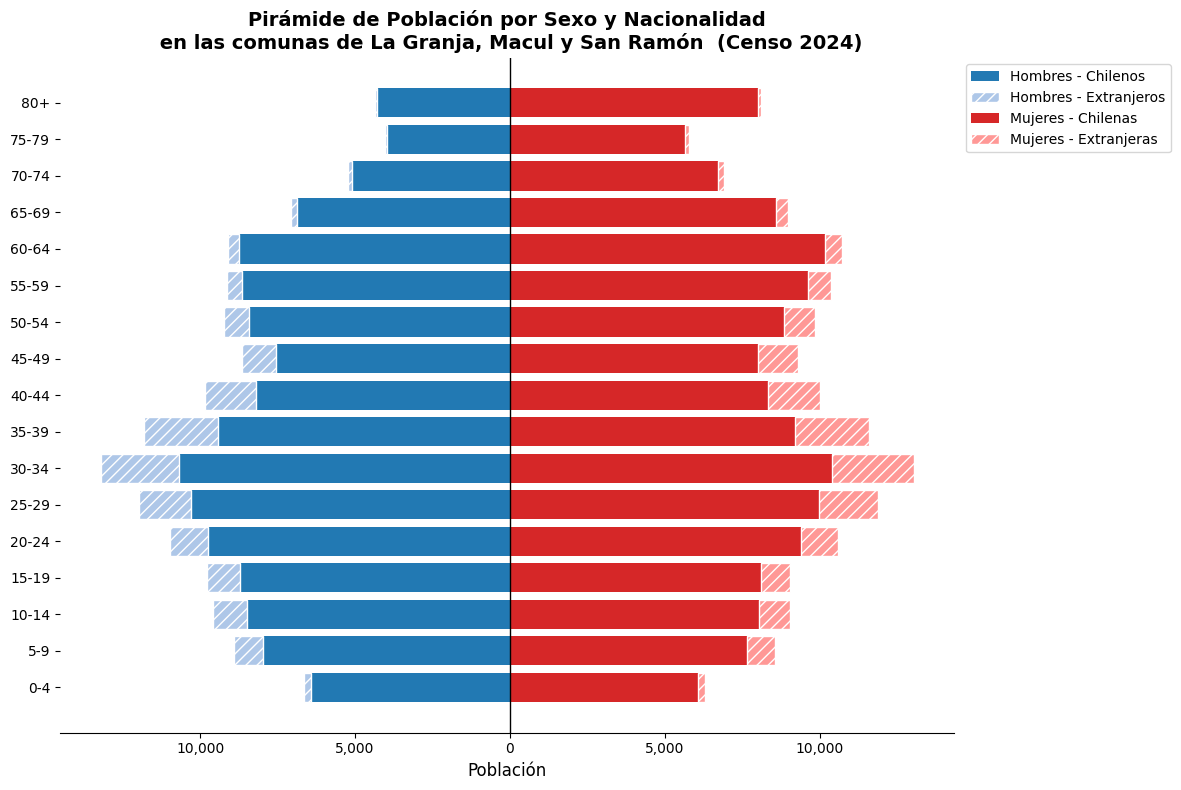

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 1. Filtramos los datos sin edad (-99)
df_pyramid = df[df["edad"] != -99].copy()

# 2. Creamos los "bins" (grupos de edad) exactamente como pidió el profesor
bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]
df_pyramid["age_group"] = pd.cut(df_pyramid["edad"], bins=bins, labels=labels, right=False)

# 3. Agrupamos y contamos a las personas
# Nota: En el INE, "sexo" suele ser 1=Hombre, 2=Mujer.
# "p25_lug_nacimiento_rec" suele ser 1=Chilena, 2=Extranjera.
conteo = df_pyramid.pivot_table(
    index="age_group",
    columns=["sexo", "p25_lug_nacimiento_rec"],
    aggfunc="size",
    fill_value=0
)

# Extraemos las 4 series (si los códigos del diccionario cambian, avísame y los ajustamos)
# Usamos .get() por si acaso algún cruce diera 0 y no exista la columna
hombres_chilenos    = conteo.get((1, 1), pd.Series(0, index=labels))
hombres_extranjeros = conteo.get((1, 2), pd.Series(0, index=labels))
mujeres_chilenas    = conteo.get((2, 1), pd.Series(0, index=labels))
mujeres_extranjeras = conteo.get((2, 2), pd.Series(0, index=labels))

#Convertimos a los hombres en negativos para que crezcan hacia la izquierda
hombres_chilenos = -hombres_chilenos
hombres_extranjeros = -hombres_extranjeros

# 4. Dibujamos el gráfico
fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(labels))

# Barras de Hombres (Izquierda)
# Apilamos a los extranjeros "a la izquierda" de los chilenos usando el parámetro 'left'
ax.barh(y_pos, hombres_chilenos, color="#2279b3", label='Hombres - Chilenos')
ax.barh(y_pos, hombres_extranjeros, left=hombres_chilenos, color='#aec7e8',
        edgecolor='white', hatch='///', label='Hombres - Extranjeros')

# Barras de Mujeres (Derecha)
# Apilamos a las extranjeras "a la derecha" de las chilenas
ax.barh(y_pos, mujeres_chilenas, color='#d62728', label='Mujeres - Chilenas')
ax.barh(y_pos, mujeres_extranjeras, left=mujeres_chilenas, color='#ff9896',
        edgecolor='white', hatch='///', label='Mujeres - Extranjeras')

# 5. Configuración visual y diseño
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_title('Pirámide de Población por Sexo y Nacionalidad\n en las comunas de La Granja, Macul y San Ramón  (Censo 2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Población', fontsize=12)

# Este formateador quita el signo negativo (-) del eje X para que se vea profesional
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{abs(int(x)):,}"))

# Agregamos una línea central vertical en el cero para dividir hombres y mujeres
ax.axvline(0, color='black', linewidth=1)

# Movemos la leyenda a un lugar donde no tape las barras
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))

# Eliminamos los bordes superior y derecho del gráfico para un look más limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout(); # El punto y coma evita que se imprima texto basura

### 1.2 Dependency ratio (0.5 pts)

Compute the **age dependency ratio** for each of your comunas:

$$\text{Dependency ratio} = \frac{\text{population aged 0-14} + \text{population aged 65+}}{\text{population aged 15-64}}$$

Present the result as a small table with one row per comuna.
Briefly comment: is the ratio higher or lower than you expected?

In [7]:
# Construimos la razón de dependencia (total)
population_aged_0_14 = df[df["edad"].between(0, 14)].shape[0]  # contamos la población entre 0 y 14 años
population_aged_15_64 = df[df["edad"].between(15, 64)].shape[0]  # contamos la población entre 15 y 64 años
population_aged_65_plus = df[df["edad"] >= 65].shape[0]  # contamos la población de 65 años o más

# Calculamos la razón de dependencia total
dependency_ratio = (population_aged_0_14 + population_aged_65_plus) / population_aged_15_64
print(f"Razón de dependencia (total): {dependency_ratio:.2f}")

# Map de códigos a nombres de comuna para mostrar nombres en la tabla
code_to_name = {13111: "La Granja", 13118: "Macul", 13131: "San Ramón"}

# Creamos la tabla de razón de dependencia por comuna (usando los códigos en MY_COMUNAS)
dependency_table = df[df["comuna"].isin(MY_COMUNAS)].groupby("comuna").apply(
    lambda x: (x["edad"].between(0, 14).sum() + x["edad"].ge(65).sum()) / x["edad"].between(15, 64).sum()
).reset_index(name="Dependency Ratio")
# Añadimos la columna con el nombre de la comuna y reordenamos para mostrar el nombre primero
dependency_table["comuna_nombre"] = dependency_table["comuna"].map(code_to_name)
dependency_table = dependency_table[["comuna_nombre", "Dependency Ratio"]].rename(columns={"comuna_nombre": "comuna"})
print(dependency_table)  # imprimimos la tabla de razón de dependencia por comuna con nombres

Razón de dependencia (total): 0.47
      comuna  Dependency Ratio
0  La Granja          0.498642
1      Macul          0.441328
2  San Ramón          0.496692


Un valor de 0,5 indica que hay 1 persona dependiente (niño o adulto mayor) por cada 2 personas en edad productiva, mientras que 1,0 implica igual número de dependientes y personas en edad de trabajar; cifras mayores a 1,0 representan una carga de dependencia alta y mayor presión sobre servicios sociales y economía local, y en estas comunas la razón general es ~0,47, con La Granja y San Ramón en 0,49 (algo sobre el promedio del grupo) y Macul en 0,44 (por debajo), lo que indica una carga moderada en conjunto pero ligeramente más pesada en La Granja y San Ramón.

### 1.3 Household size distribution (0.5 pts)

Using the joined table, compute the number of persons per household
(`id_hogar`).  Plot the distribution as a bar chart (x-axis:
household size 1, 2, 3, ..., 8+; y-axis: count or proportion).

Break it down by nationality group (Chilean vs. Foreign head of
household, or all members).  Comment on any visible differences.

<>:34: SyntaxWarning: invalid escape sequence '\R'
<>:34: SyntaxWarning: invalid escape sequence '\R'
C:\Users\javie\AppData\Local\Temp\ipykernel_22364\4251055186.py:34: SyntaxWarning: invalid escape sequence '\R'
  plt.title('Distribución del Tamaño del Hogar según Nacionalidad del Jefe/a\Región Metropolitana (Censo 2024)', fontsize=14, fontweight='bold') # establecemos el título del gráfico con un tamaño de fuente de 14 y negrita


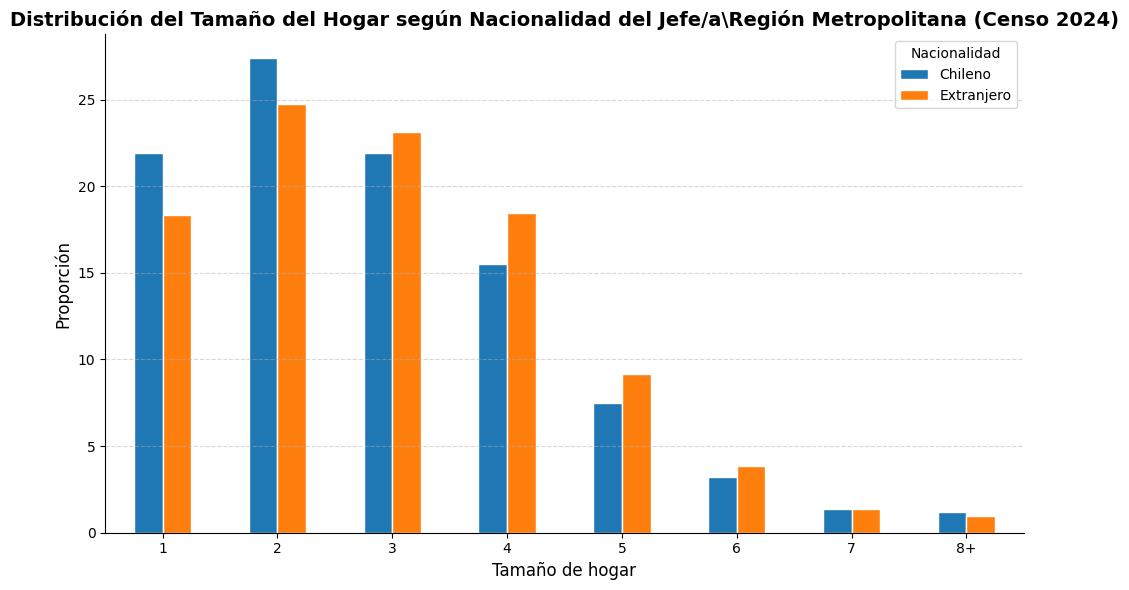

In [8]:
# 1.3 Household size distribution (0.5 pts)
import matplotlib.pyplot as plt

# 1. Calcular el tamaño de cada hogar (contando cuántas filas hay por cada id_hogar)
hh_sizes = df.groupby(['id_vivienda', 'id_hogar']).size().reset_index(name='hh_size')

# 2. Agrupar tamaños de 8 o más en una sola categoría "8+"
hh_sizes['hh_size_capped'] = hh_sizes['hh_size'].apply(lambda x: '8+' if x >= 8 else str(x))

# 3. Obtener la nacionalidad del Jefe/a de Hogar
# Asumimos que la primera persona registrada (el id_persona más bajo) es el Jefe/a de Hogar
hh_heads = df.sort_values('id_persona').groupby(['id_vivienda', 'id_hogar'])['p25_lug_nacimiento_rec'].first().reset_index() # obtenemos la nacionalidad del jefe/a de hogar asumiendo que es la persona con el id_persona más bajo dentro de cada hogar, agrupamos por id_vivienda e id_hogar y tomamos el primer valor de p25_lug_nacimiento_rec para cada grupo, lo que nos da la nacionalidad del jefe/a de hogar en una nueva tabla llamada hh_heads

# 4. Unir ambas tablas (tamaño del hogar + nacionalidad del jefe)
hh_data = pd.merge(hh_sizes, hh_heads, on=['id_vivienda', 'id_hogar']) # unimos la tabla de tamaños de hogar con la tabla de nacionalidad del jefe/a de hogar utilizando las columnas id_vivienda e id_hogar como claves de unión, lo que nos da una nueva tabla llamada hh_data que contiene tanto el tamaño del hogar como la nacionalidad del jefe/a de hogar para cada hogar

# Filtramos para quedarnos solo con Chilenos (código 1) y Extranjeros (código 2)
# (Si tu diccionario tiene otros códigos para nacionalidad_rec, ajusta estos números)
hh_data = hh_data[hh_data['p25_lug_nacimiento_rec'].isin([1, 2])].copy() # filtramos el DataFrame hh_data para quedarnos solo con las filas donde la columna p25_lug_nacimiento_rec tenga los valores 1 o 2, lo que corresponde a Chilenos y Extranjeros respectivamente, y hacemos una copia del resultado para evitar advertencias de pandas sobre la asignación de valores a una vista del DataFrame original
hh_data['Nacionalidad'] = hh_data['p25_lug_nacimiento_rec'].map({1: 'Chileno', 2: 'Extranjero'}) # creamos una nueva columna "Nacionalidad" en el DataFrame hh_data mapeando los valores de p25_lug_nacimiento_rec a "Chileno" para el código 1 y "Extranjero" para el código 2, lo que nos permite tener una columna con nombres legibles en lugar de códigos numéricos para la nacionalidad del jefe/a de hogar

# 5. Calcular las proporciones (%) dentro de cada grupo
conteo = hh_data.groupby(['Nacionalidad', 'hh_size_capped']).size().unstack(fill_value=0) # contamos el número de hogares para cada combinación de Nacionalidad y hh_size_capped, y luego usamos unstack para convertir la columna hh_size_capped en columnas separadas, rellenando con 0 donde no haya datos
proporciones = conteo.div(conteo.sum(axis=1), axis=0) * 100 # calculamos la proporción de cada tamaño de hogar dentro de cada grupo de nacionalidad dividiendo el conteo de cada tamaño por el total de hogares en ese grupo (sumando a lo largo de las columnas) y multiplicando por 100 para obtener un porcentaje

# Ordenar las columnas explícitamente para que el gráfico quede secuencial
orden_columnas = ['1', '2', '3', '4', '5', '6', '7', '8+'] # definimos el orden de las columnas para que se muestren secuencialmente en el gráfico, asegurándonos de incluir la categoría "8+" al final
proporciones = proporciones.reindex(columns=orden_columnas) # reordenamos las columnas del DataFrame de proporciones según el orden definido en orden_columnas, lo que garantiza que los tamaños de hogar se muestren en secuencia en el gráfico de barras agrupadas

# 6. Dibujar el gráfico de barras agrupadas
ax = proporciones.T.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'], edgecolor='white') # dibujamos un gráfico de barras agrupadas a partir del DataFrame de proporciones, transponiendo el DataFrame para que los tamaños de hogar estén en el eje x y las nacionalidades en el eje y, especificando el tipo de gráfico como 'bar', el tamaño de la figura, los colores para cada grupo y un borde blanco para mejorar la legibilidad

# Configuración visual
plt.title('Distribución del Tamaño del Hogar según Nacionalidad del Jefe/a\Región Metropolitana (Censo 2024)', fontsize=14, fontweight='bold') # establecemos el título del gráfico con un tamaño de fuente de 14 y negrita
plt.xlabel('Número de personas en el hogar', fontsize=12)
plt.ylabel('Proporción del grupo (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Jefatura de Hogar')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Limpiar bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout();
ax.set_xlabel("Tamaño de hogar") # establecemos la etiqueta del eje x
ax.set_ylabel("Proporción") # establecemos la etiqueta del eje y
ax.legend(title="Nacionalidad") # agregamos una leyenda al gráfico con el título "Nacionalidad"
plt.xticks(rotation=0) # rotamos las etiquetas del eje x para que se lean horizontalmente
plt.tight_layout() # ajustamos el diseño del gráfico para que no se solapen los elementos

### 1.4 Education and employment (1 pt)

For each of your comunas, compute:

- **Mean years of schooling** (`escolaridad`) for the population
  aged 25+, separately for Chilean-born and foreign-born.
- **Employment rate** among the population aged 15-64:
  the share with `sit_fuerza_trabajo` indicating employment (consult
  the variable dictionary for the code).

Present these as a grouped bar chart (one group per comuna, bars for
Chilean and Foreign).  Comment on any differences.

Mean schooling 25+ (years):
nacionalidad    Chileno  Extranjero
comuna                             
13111         10.856734   12.150499
13118         13.336334   14.598976
13131         10.520867   11.916823

Employment rate 15-64:
nacionalidad   Chileno  Extranjero
comuna                            
13111         0.593572    0.721394
13118         0.691404    0.811891
13131         0.603260    0.738268


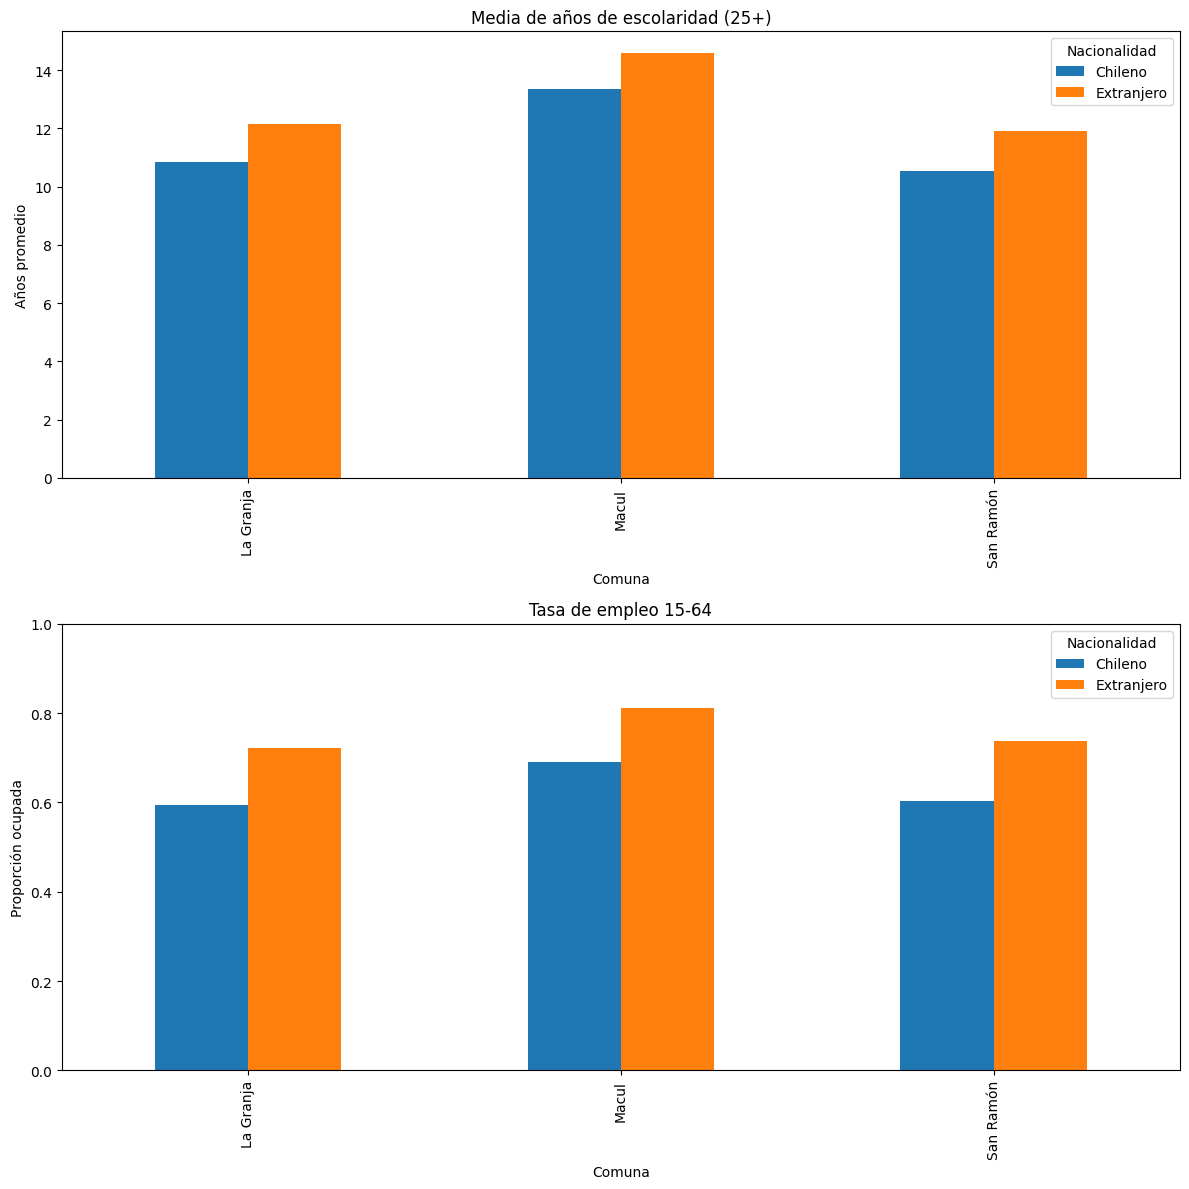

In [9]:
# 1.4 Education and employment (1 pt)

import numpy as np
import matplotlib.pyplot as plt

# Rangos de edad y limpieza de -99
pop_25 = df[df["edad"].between(25, 120)] # filtramos el DataFrame para quedarnos solo con las personas que tienen entre 25 y 120 años, lo que nos da la población de 25 años o más
pop_15_64 = df[df["edad"].between(15, 64)] # filtramos el DataFrame para quedarnos solo con las personas que tienen entre 15 y 64 años, lo que nos da la población en edad laboral

pop_25_clean = pop_25[pop_25["escolaridad"] != -99].copy() # filtramos el DataFrame de población de 25 años o más para quedarnos solo con las filas donde la columna escolaridad no tenga el valor -99, lo que nos da un DataFrame limpio de personas con información válida sobre su nivel de escolaridad, y hacemos una copia del resultado para evitar advertencias de pandas sobre la asignación de valores a una vista del DataFrame original
pop_15_64_clean = pop_15_64[pop_15_64["sit_fuerza_trabajo"] != -99].copy() # filtramos el DataFrame de población en edad laboral para quedarnos solo con las filas donde la columna sit_fuerza_trabajo no tenga el valor -99, lo que nos da un DataFrame limpio de personas con información válida sobre su situación en la fuerza laboral, y hacemos una copia del resultado para evitar advertencias de pandas sobre la asignación de valores a una vista del DataFrame original

# Nacionalidad clara
pop_25_clean["nacionalidad"] = pop_25_clean["p25_lug_nacimiento_rec"].map({1: "Chileno", 2: "Extranjero"}) # creamos una nueva columna "nacionalidad" en el DataFrame pop_25_clean mapeando los valores de p25_lug_nacimiento_rec a "Chileno" para el código 1 y "Extranjero" para el código 2, lo que nos permite tener una columna con nombres legibles en lugar de códigos numéricos para la nacionalidad de las personas de 25 años o más
pop_15_64_clean["nacionalidad"] = pop_15_64_clean["p25_lug_nacimiento_rec"].map({1: "Chileno", 2: "Extranjero"}) # creamos una nueva columna "nacionalidad" en el DataFrame pop_15_64_clean mapeando los valores de p25_lug_nacimiento_rec a "Chileno" para el código 1 y "Extranjero" para el código 2, lo que nos permite tener una columna con nombres legibles en lugar de códigos numéricos para la nacionalidad de las personas en edad laboral

# Media de escolaridad 25+
mean_school = pop_25_clean.groupby(["comuna", "nacionalidad"])["escolaridad"].mean().unstack().fillna(0) # agrupamos el DataFrame pop_25_clean por comuna y nacionalidad, calculamos la media de la columna escolaridad para cada grupo, luego usamos unstack para convertir la columna nacionalidad en columnas separadas, y rellenamos con 0 donde no haya datos, lo que nos da un DataFrame con la media de años de escolaridad para cada combinación de comuna y nacionalidad

# Tasa de empleo 15-64
employed_counts = pop_15_64_clean[pop_15_64_clean["sit_fuerza_trabajo"] == 1].groupby(["comuna", "nacionalidad"]).size() # filtramos el DataFrame pop_15_64_clean para quedarnos solo con las filas donde la columna sit_fuerza_trabajo tenga el valor 1, lo que corresponde a personas que están empleadas, luego agrupamos por comuna y nacionalidad y contamos el número de personas en cada grupo, lo que nos da un Series con el conteo de personas empleadas para cada combinación de comuna y nacionalidad
base_counts = pop_15_64_clean.groupby(["comuna", "nacionalidad"]).size() # agrupamos el DataFrame pop_15_64_clean por comuna y nacionalidad y contamos el número de personas en cada grupo, lo que nos da un Series con el conteo total de personas en edad laboral para cada combinación de comuna y nacionalidad
emp_rate = (employed_counts / base_counts).unstack().fillna(0) # calculamos la tasa de empleo dividiendo el conteo de personas empleadas por el conteo total de personas en edad laboral para cada grupo, luego usamos unstack para convertir la columna nacionalidad en columnas separadas, y rellenamos con 0 donde no haya datos, lo que nos da un DataFrame con la tasa de empleo para cada combinación de comuna y nacionalidad

print("Mean schooling 25+ (years):") # imprimimos el título para la media de años de escolaridad de las personas de 25 años o más
print(mean_school) 
print("\nEmployment rate 15-64:") # imprimimos el título para la tasa de empleo de las personas entre 15 y 64 años
print(emp_rate)

# mapeo de código a nombre usando el dict ya definido
mean_school = mean_school.rename(index=code_to_name)
emp_rate = emp_rate.rename(index=code_to_name)

# Gráficos
fig, ax = plt.subplots(2, 1, figsize=(12, 12))
mean_school.plot(kind="bar", ax=ax[0]) # dibujamos un gráfico de barras para la media de años de escolaridad utilizando el DataFrame mean_school, especificando el eje ax[0] para colocar este gráfico en la primera posición del arreglo de subplots
ax[0].set_title("Media de años de escolaridad (25+)")
ax[0].set_xlabel("Comuna")
ax[0].set_ylabel("Años promedio")
ax[0].legend(title="Nacionalidad")

emp_rate.plot(kind="bar", ax=ax[1]) # dibujamos un gráfico de barras para la tasa de empleo utilizando el DataFrame emp_rate, especificando el eje ax[1] para colocar este gráfico en la segunda posición del arreglo de subplots
ax[1].set_title("Tasa de empleo 15-64")
ax[1].set_xlabel("Comuna")
ax[1].set_ylabel("Proporción ocupada")
ax[1].set_ylim(0, 1)
ax[1].legend(title="Nacionalidad")

plt.tight_layout()

Al observar los gráficos de barras agrupadas para las comunas de la granja, macul y san ramon, tenemos que:

Años Promedio de Escolaridad (Población 25+ años):
Respecto de la longitud de las barras presentes en el grafico, las 3 comunas suelen seguir la misma tendencia, es decir, la poblacion extranjera suele tener mas años de escolaridad que la poblacion nacional debido a que deberian regularizar y convalidad su nivel de estudio con el de nuestro pais.

Tasa de Ocupación (Población 15-64 años):
El gráfico de ocupación muestra la diferencia mucho mas notoria a favor de los extranjeros: . En prácticamente todas las comunas, la barra correspondiente a la población extranjera es visiblemente más alta que la de la población local.

Esto se puede inferir de la situacion de migración actual que se encuentra nuestro pais, la cual principalmente se relaciona netamente al escenario económico y laboral las cuales podrian estar relacionadas a trabajos de comercio,de servicios basicos, etc. Esto tambien se podria deber a que a población migrante tiene como principal objetivo trabajar para subsistir en nuestro pais y enviar dinero a sus familias en el extranjero, lo que reduce drásticamente sus tasas de inactividad como dedicarse solo a estudiar o labores de cuidado no remuneradas en comparación con la población chilena en el mismo tramo de edad.

---

## Part 2: Migration Landscape (3 pts)

### 2.1 Percentage foreign-born by comuna (0.5 pts)

For each of your assigned comunas, compute the percentage of
foreign-born residents.  Present as a simple table and as a bar chart.

  comuna_nombre  pop_total  pop_foreign  pct_foreign
0     La Granja     112022         9550     8.525111
1         Macul     123800        17497    14.133279
2     San Ramón      76002         6214     8.176101


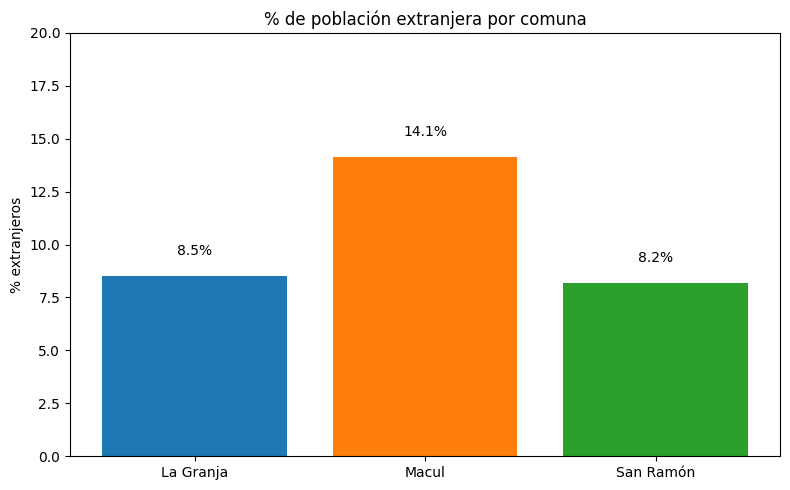

In [10]:
# 2.1 Percentage foreign-born by comuna (0.5 pts)
import matplotlib.pyplot as plt
by_comuna = df.groupby('comuna')['p25_lug_nacimiento_rec'].agg( # agrupamos el DataFrame por comuna y aplicamos funciones de agregación a la columna p25_lug_nacimiento_rec para calcular el total de personas y el número de personas extranjeras en cada comuna
    pop_total='size', # calculamos el total de personas en cada comuna utilizando la función 'size', que cuenta el número de filas en cada grupo
    pop_foreign=lambda x: (x == 2).sum() # calculamos el número de personas extranjeras en cada comuna utilizando una función lambda que cuenta cuántas veces el valor 2 (que corresponde a extranjeros) aparece en la columna p25_lug_nacimiento_rec para cada grupo de comuna
).reset_index() # restablecemos el índice del DataFrame resultante para que la columna comuna vuelva a ser una columna normal en lugar de un índice
by_comuna['pct_foreign'] = 100 * by_comuna['pop_foreign'] / by_comuna['pop_total'] # calculamos el porcentaje de población extranjera en cada comuna dividiendo el número de personas extranjeras por el total de personas en esa comuna y multiplicando por 100 para obtener un porcentaje
by_comuna['comuna_nombre'] = by_comuna['comuna'].map({13111: 'La Granja', 13118: 'Macul', 13131: 'San Ramón'}) # mapeamos los códigos de comuna a nombres legibles utilizando un diccionario, creando una nueva columna comuna_nombre en el DataFrame by_comuna con los nombres correspondientes a cada código de comuna
print(by_comuna[['comuna_nombre', 'pop_total', 'pop_foreign', 'pct_foreign']]) # imprimimos una tabla con el nombre de la comuna, el total de población, el número de personas extranjeras y el porcentaje de población extranjera para cada comuna
fig, ax = plt.subplots(figsize=(8,5)) # creamos una figura y un eje para el gráfico de barras con un tamaño de 8x5 pulgadas
ax.bar(by_comuna['comuna_nombre'], by_comuna['pct_foreign'], color=['#1f77b4', '#ff7f0e', '#2ca02c']) # dibujamos un gráfico de barras utilizando el método bar del eje ax, con el nombre de la comuna en el eje x y el porcentaje de población extranjera en el eje y, especificando colores diferentes para cada barra
ax.set_title('% de población extranjera por comuna') # establecemos el título del gráfico como "% de población extranjera por comuna"
ax.set_ylabel('% extranjeros') # establecemos la etiqueta del eje y como "% extranjeros"
ax.set_ylim(0, 20) # establecemos el límite del eje y de 0 a 20 para que el gráfico muestre correctamente los porcentajes
for i, v in enumerate(by_comuna['pct_foreign']): # iteramos sobre los valores del porcentaje de población extranjera para cada comuna utilizando enumerate para obtener tanto el índice (i) como el valor (v) de cada barra en el gráfico
    ax.text(i, v + 1, f'{v:.1f}%', ha='center') # agregamos etiquetas de texto encima de cada barra para mostrar el porcentaje con un decimal, utilizando el método text del eje ax, posicionando el texto en el centro horizontalmente (ha='center') y un poco por encima del valor de la barra (v + 1) para que no se superponga con la barra
plt.tight_layout() # ajustamos el diseño del gráfico para que no se solapen los elementos y se vea bien


### 2.2 Top nationalities (1 pt)

Using `p27_nacionalidad_esp` (the detailed nationality variable, not
the recoded one), show the **top 10 nationalities** among
foreign-born residents in your comunas.  Present as a horizontal
bar chart.

Consult the variable dictionary to decode the numeric codes into
country names.  If the dictionary uses numeric codes, create a
mapping dictionary in your notebook.

p27_nacionalidad_esp
Venezuela                                      17261
Perú                                            4982
Colombia                                        3473
Chile                                           2730
Haití                                           1648
Otros países de América del Sur                 1113
Otros países de América Central y El Caribe      686
Bolivia                                          450
Argentina                                        414
Asia                                             231
Name: count, dtype: int64


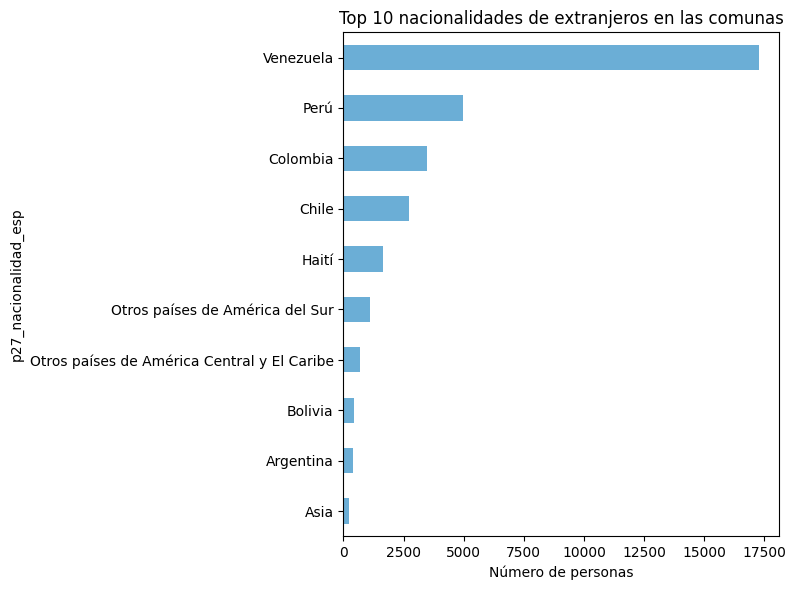

In [11]:
# 2.2 Top nationalities among foreign-born (1 pt)
import matplotlib.pyplot as plt
foreign = df[df['p25_lug_nacimiento_rec'] == 2].copy() # filtramos el DataFrame para quedarnos solo con las filas donde la columna p25_lug_nacimiento_rec tenga el valor 2, lo que corresponde a personas extranjeras, y hacemos una copia del resultado para evitar advertencias de pandas sobre la asignación de valores a una vista del DataFrame original
top_nat = foreign['p27_nacionalidad_esp'].value_counts().head(10) # contamos el número de personas para cada nacionalidad utilizando value_counts() en la columna p27_nacionalidad_esp del DataFrame foreign, y luego usamos head(10) para quedarnos solo con las 10 nacionalidades más comunes entre la población extranjera
country_map = {2: 'África', 5: 'Otros países de América del Sur', 9: 'Oceanía', 10: 'Antártica (continente)', 13: 'Otros países de América Central y El Caribe', 21: 'América del Norte', 32: 'Argentina', 68: 'Bolivia', 142: 'Asia', 150: 'Europa', 152: 'Chile', 170:'Colombia', 332: 'Haití', 604: 'Perú', 862: 'Venezuela'} # definimos un diccionario que mapea los códigos de nacionalidad a nombres legibles, lo que nos permitirá mostrar los nombres de las nacionalidades en lugar de los códigos numéricos en el gráfico y la tabla
top_nat.index = top_nat.index.map(lambda x: country_map.get(x, f'Código {x}')) # mapeamos los índices del Series top_nat utilizando el diccionario country_map, reemplazando cada código de nacionalidad con su nombre correspondiente, y si un código no está en el diccionario, se mostrará como "Código {x}" para indicar que es un código desconocido
print(top_nat) # imprimimos el Series top_nat que contiene las 10 nacionalidades más comunes entre la población extranjera, con los nombres de las nacionalidades como índices y el conteo de personas como valores
fig, ax = plt.subplots(figsize=(8,6)) # creamos una figura y un eje para el gráfico de barras horizontales con un tamaño de 8x6 pulgadas
top_nat.sort_values().plot(kind='barh', ax=ax, color='#6baed6') # dibujamos un gráfico de barras horizontales utilizando el método plot con kind='barh' en el Series top_nat, ordenando los valores de menor a mayor para que la barra más larga esté en la parte superior, especificando el eje ax para colocar el gráfico en el eje creado y un color específico para las barras
ax.set_title('Top 10 nacionalidades de extranjeros en las comunas') # establecemos el título del gráfico como "Top 10 nacionalidades de extranjeros en las comunas"
ax.set_xlabel('Número de personas') # establecemos la etiqueta del eje x como "Número de personas"
plt.tight_layout() # ajustamos el diseño del gráfico para que no se solapen los elementos y se vea bien


### 2.3 Migration status: residence 5 years ago (1 pt)

The variable `p24_lug_resid5` captures where the person lived 5
years before the census.  Using the variable dictionary, decode this
variable and compute the following for your comunas combined:

- % who lived in the **same comuna**
- % who lived in a **different comuna, same region**
- % who lived in a **different region**
- % who lived **abroad**

Present as a stacked bar chart broken down by comuna.  Filter out
missing values and people younger than 5 (who were not alive 5 years
ago).

status     En esta comuna  En otra comuna  En otro país
comuna                                                 
La Granja       84.083094       12.155071      3.761835
Macul           71.794545       24.174770      4.030684
San Ramón       84.599484       11.682528      3.717988


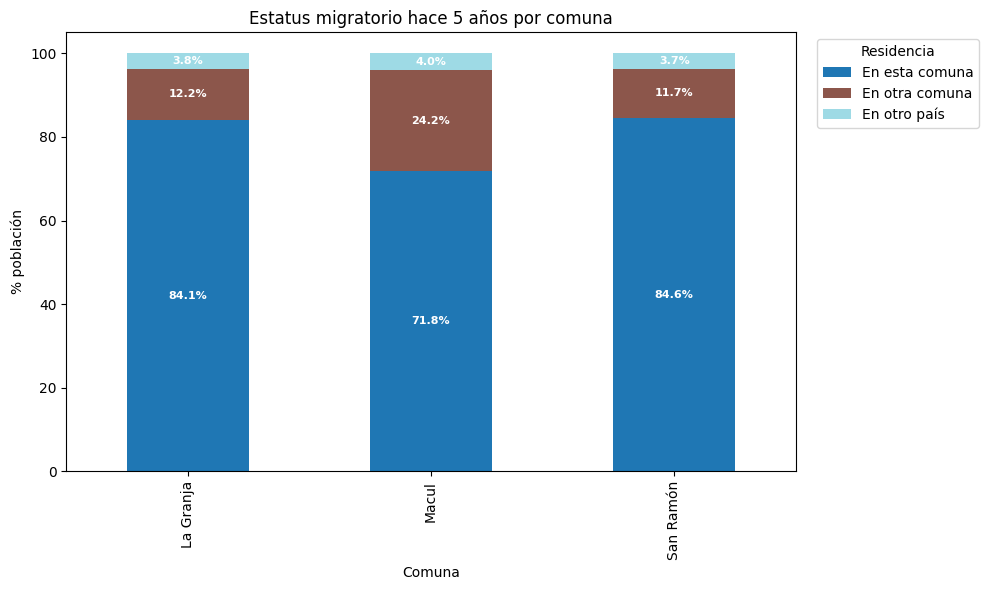

In [19]:
# 2.3 Migration status: residence 5 years ago (1 pt)
resid5 = df[(df['edad'] >= 5) & (df['p24_lug_resid5'] != -99)].copy() # filtramos el DataFrame para quedarnos solo con las filas donde la edad sea mayor o igual a 5 años y la columna p24_lug_resid5 no tenga el valor -99, lo que nos da un DataFrame limpio de personas que tienen información válida sobre su lugar de residencia hace 5 años, y hacemos una copia del resultado para evitar advertencias de pandas sobre la asignación de valores a una vista del DataFrame original
resid5['status'] = resid5['p24_lug_resid5'].map({1: 'Aún no nacía', 2: 'En esta comuna', 3: 'En otra comuna', 4: 'En otro país', -99: 'No respuesta'}) # creamos una nueva columna "status" en el DataFrame resid5 mapeando los valores de p24_lug_resid5 a categorías legibles, lo que nos permite tener una columna con nombres descriptivos para el estatus migratorio de las personas hace 5 años en lugar de códigos numéricos
summary_resid5 = resid5.groupby(['comuna', 'status']).size().unstack(fill_value=0) # agrupamos el DataFrame resid5 por comuna y status, contamos el número de personas en cada grupo utilizando size(), y luego usamos unstack para convertir la columna status en columnas separadas, rellenando con 0 donde no haya datos, lo que nos da un DataFrame con el conteo de personas para cada combinación de comuna y estatus migratorio hace 5 años
summary_resid5.index = summary_resid5.index.map(code_to_name) # mapeamos los índices del DataFrame summary_resid5 utilizando el diccionario code_to_name para reemplazar los códigos de comuna con sus nombres correspondientes, lo que hace que el DataFrame sea más legible al mostrar los nombres de las comunas en lugar de los códigos numéricos
summary_resid5_pct = summary_resid5.div(summary_resid5.sum(axis=1), axis=0) * 100 # calculamos el porcentaje de cada categoría de estatus migratorio dentro de cada comuna dividiendo el conteo de cada categoría por la suma total de personas en esa comuna (sumando a lo largo de las columnas) y multiplicando por 100 para obtener un porcentaje, lo que nos da un DataFrame con los porcentajes de cada estatus migratorio para cada comuna
print(summary_resid5_pct) # imprimimos el DataFrame summary_resid5_pct que contiene los porcentajes de cada categoría de estatus migratorio hace 5 años para cada comuna, con las categorías de estatus como columnas y las comunas como filas
fig, ax = plt.subplots(figsize=(10,6)) # creamos una figura y un eje para el gráfico de barras apiladas con un tamaño de 10x6 pulgadas
summary_resid5_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20') # dibujamos un gráfico de barras apiladas utilizando el método plot con kind='bar' y stacked=True en el DataFrame summary_resid5_pct, especificando el eje ax para colocar el gráfico en el eje creado y un colormap para asignar colores automáticamente a cada categoría de estatus migratorio
# Agregamos etiquetas de porcentaje dentro de cada barra para mostrar el valor exacto de cada categoría dentro de las barras apiladas, iterando sobre
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            p.get_y() + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=8,
            fontweight='bold',
            color="white"  # opcional, si fondo oscuro
        )

ax.set_ylabel('% población') # establecemos la etiqueta del eje y como "% población"
ax.set_title('Estatus migratorio hace 5 años por comuna') # establecemos el título del gráfico como "Estatus migratorio hace 5 años por comuna"
ax.set_xlabel('Comuna') # establecemos la etiqueta del eje x como "Comuna"
ax.legend(title='Residencia', bbox_to_anchor=(1.02, 1), loc='upper left') # configuramos la leyenda para que tenga el título "Residencia" y se ubique fuera del gráfico a la derecha, utilizando bbox_to_anchor para posicionarla y loc para especificar la ubicación dentro del área definida por bbox_to_anchor
plt.tight_layout() # ajustamos el diseño del gráfico para que no se solapen los elementos y se vea bien


### 2.4 Arrival period of immigrants (0.5 pts)

Among foreign-born residents, use `p26_llegada_periodo` to show
**when they arrived** in Chile.  Plot the distribution as a bar
chart.  Comment: is immigration to your comunas a recent phenomenon
or does it have a longer history?


p26_llegada_periodo
Entre 2023 y 2024     3306
2020-2022             7271
2017-2019            12671
2014-2016             4299
2010-2013             1735
2000-2009             2297
1990-1999             1019
Antes de 1990          572
Name: count, dtype: int64


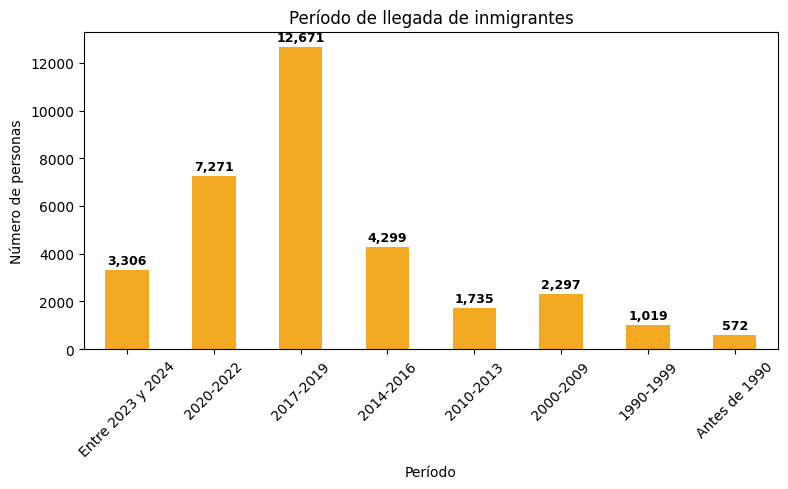

In [ ]:
# 2.4 Arrival period of immigrants (0.5 pts)
immigrants = df[df['p25_lug_nacimiento_rec'] == 2].copy()  # filtramos el DataFrame para quedarnos solo con las filas donde la columna p25_lug_nacimiento_rec tenga el valor 2, lo que corresponde a personas extranjeras, y hacemos una copia del resultado para evitar advertencias de pandas sobre la asignación de valores a una vista del DataFrame original
immigrants = immigrants[immigrants['p26_llegada_periodo'] != -99] # filtramos el DataFrame immigrants para quedarnos solo con las filas donde la columna p26_llegada_periodo no tenga el valor -99, lo que nos da un DataFrame limpio de inmigrantes con información válida sobre su período de llegada, y asignamos el resultado de nuevo
period_counts = immigrants['p26_llegada_periodo'].value_counts().sort_index() # contamos el número de inmigrantes para cada período de llegada utilizando value_counts() en la columna p26_llegada_periodo, y luego usamos sort_index() para ordenar los resultados por el código del período de llegada, lo que nos da un Series con el conteo de inmigrantes para cada período de llegada ordenado por código
period_label = {1: 'Entre 2023 y 2024', 2: '2020-2022', 3: '2017-2019', 4: '2014-2016', 5: '2010-2013', 6: '2000-2009', 7: '1990-1999', 8: 'Antes de 1990'}
period_counts.index = period_counts.index.map(lambda x: period_label.get(x, f'Código {x}')) # mapeamos los índices del Series period_counts utilizando el diccionario period_label para reemplazar los códigos de período de llegada con sus nombres correspondientes, lo que hace que el Series sea más legible al mostrar los nombres de los períodos en lugar de los códigos numéricos, y si un código no está en el diccionario, se mostrará como "Código {x}" para indicar que es un código desconocido
print(period_counts) # imprimimos el Series period_counts que contiene el conteo de inmigrantes para cada período de llegada, con los nombres de los períodos como índices y el conteo de personas como valores
fig, ax = plt.subplots(figsize=(8,5)) # creamos una figura y un eje para el gráfico de barras con un tamaño de 8x5 pulgadas
period_counts.plot(kind='bar', ax=ax, color="#f3aa22") # dibujamos un gráfico de barras utilizando el método plot con kind='bar' en el Series period_counts, especificando el eje ax para colocar el gráfico en el eje creado y un color específico para las barras
# Agregamos etiquetas de conteo encima de cada barra para mostrar el número exacto de inmigrantes en cada período, iterando sobre las barras del gráfico utilizando ax.patches para obtener cada barra como un objeto Patch, y luego usando get_height() para obtener la altura de cada barra (que corresponde al conteo de inmigrantes), y si la altura es mayor que 0, agregamos un texto encima de la barra con el valor formateado con comas para miles, centrado horizontalmente (ha='center') y un poco por encima de la barra (h + max(period_counts) * 0.01) para que no se superponga con la barra
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            h + max(period_counts) * 0.01,
            f"{int(h):,}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="black"
        )
# Configuración visual
ax.set_title('Período de llegada de inmigrantes')
ax.set_xlabel('Período')
ax.set_ylabel('Número de personas')
plt.xticks(rotation=45)
plt.tight_layout()


De acuerdo al grafico se puede aprecial que el fenomeno de inmigracion hacia esas comunas es practicamente reciente. Esto aumento desde el 2010 en adelante se deberia a una ola de inmigrantes desde Venezuela, Peru, Colombia, Haiti, debido generalemnte a problemas politicos, geopoliticos, pobreza,etc.

---
## Part 3: Spatial Visualization (1 pt)

### 3.1 Choropleth map: population by comuna

Using `geopandas` and a shapefile of Chilean comunas, create a
choropleth map showing total population for each of your assigned
comunas.

Shapefile columns: ['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'geometry']
     cod_comuna   comuna  pop_total  pct_foreign
47        13131  13131.0    76002.0     8.176101
146       13111  13111.0   112022.0     8.525111
160       13118  13118.0   123800.0    14.133279


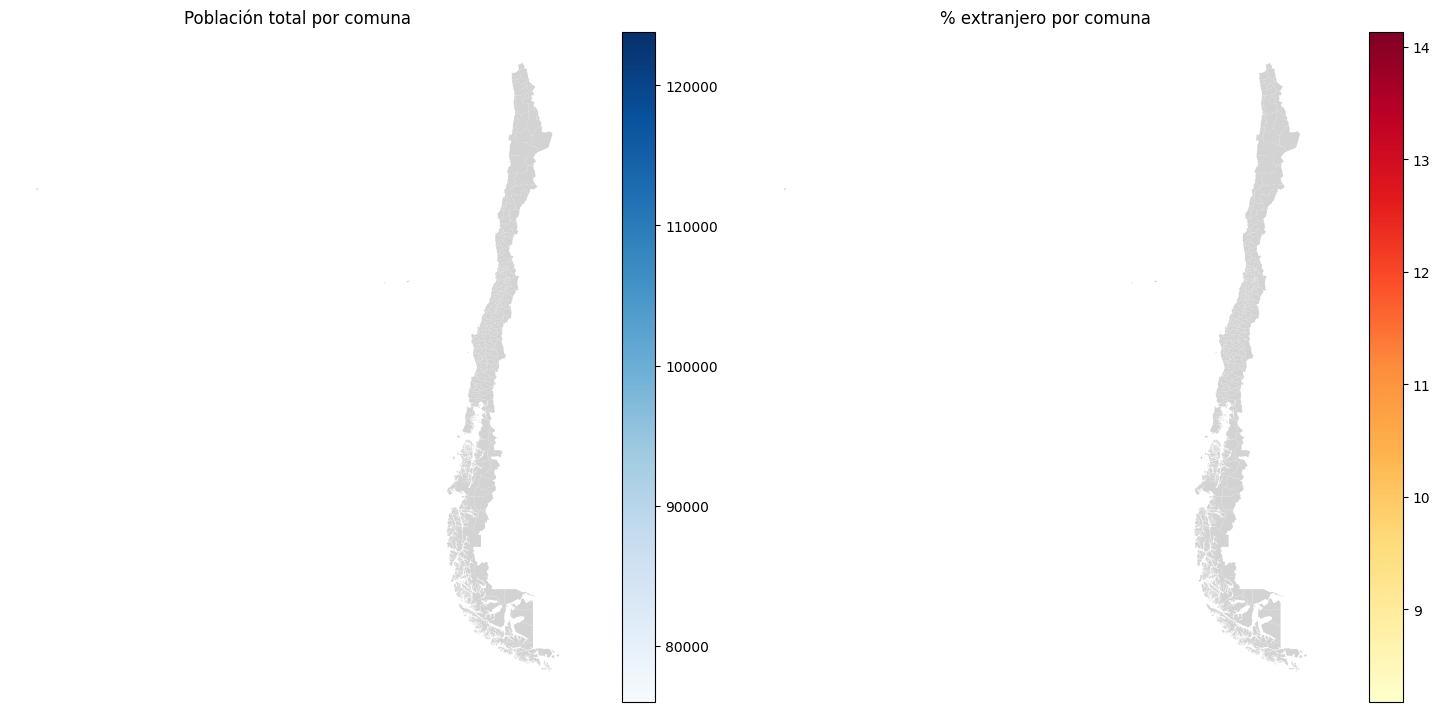

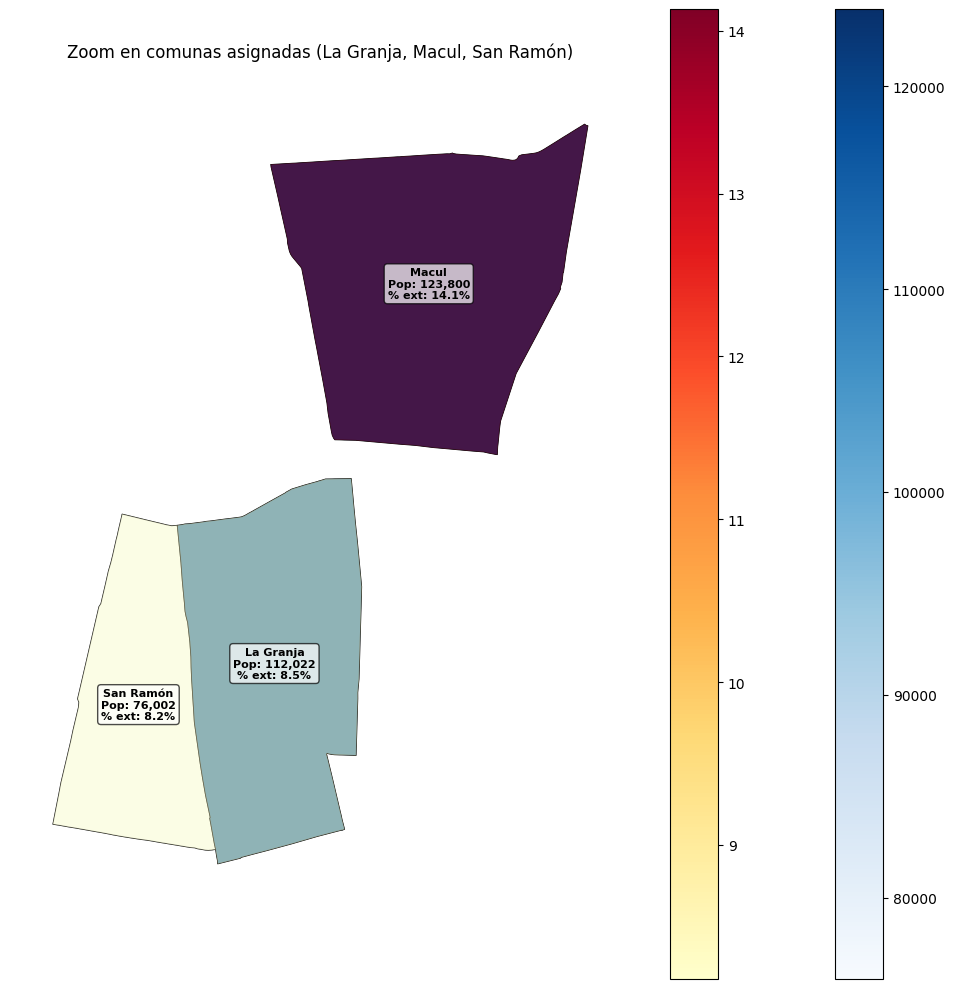

In [ ]:
# 3.1 and 3.2 Choropleth maps
import geopandas as gpd
import matplotlib.pyplot as plt

comunas_gdf = gpd.read_file("Mapa comuna/comunas.shp") # leemos el shapefile de las comunas utilizando geopandas y lo almacenamos en un GeoDataFrame llamado comunas_gdf
print("Shapefile columns:", comunas_gdf.columns.tolist()) # imprimimos la lista de columnas disponibles en el GeoDataFrame comunas_gdf para verificar qué columnas tenemos disponibles para identificar las comunas y hacer el merge con nuestros datos agregados, lo que nos ayuda a entender la estructura del shapefile y a elegir la columna correcta para el merge

# Calculamos indicadores clave si no existen
a_comunas = df.groupby("comuna").agg( # agrupamos el DataFrame por comuna y aplicamos funciones de agregación para calcular los indicadores clave necesarios para los mapas, lo que nos da un nuevo DataFrame a_comunas con una fila por cada comuna y columnas con los indicadores calculados
    pop_total=("id_persona", "size"), # calculamos el total de población en cada comuna utilizando la función 'size' en la columna id_persona, lo que nos da el conteo de personas para cada comuna y almacenamos este resultado en una nueva columna llamada pop_total
    pop_foreign=("p25_lug_nacimiento_rec", lambda x: (x == 2).sum()) # calculamos el número de personas extranjeras en cada comuna utilizando una función lambda que cuenta cuántas veces el valor 2 (que corresponde a extranjeros) aparece en la columna p25_lug_nacimiento_rec para cada grupo de comuna, y almacenamos este resultado en una nueva columna llamada pop_foreign
).reset_index() # restablecemos el índice del DataFrame resultante para que la columna comuna vuelva a ser una columna normal en lugar de un índice
a_comunas["pct_foreign"] = 100 * a_comunas["pop_foreign"] / a_comunas["pop_total"] # calculamos el porcentaje de población extranjera en cada comuna dividiendo el número de personas extranjeras por el total de personas en esa comuna y multiplicando por 100 para obtener un porcentaje, y almacenamos este resultado en una nueva columna llamada pct_foreign

# Aseguramos el tipo y nombre de columna de comuna para el merge
if "comuna" not in a_comunas.columns and "COMUNA" in a_comunas.columns: # verificamos si la columna que representa la comuna en el DataFrame a_comunas no se llama "comuna" pero sí existe una columna llamada "COMUNA", lo que indicaría que la columna de comuna está presente pero con un nombre diferente, y en ese caso, renombramos la columna "COMUNA" a "comuna" para estandarizar el nombre de la columna de comuna en ambos DataFrames antes de hacer el merge
    a_comunas = a_comunas.rename(columns={"COMUNA": "comuna"}) # verificamos si la columna que representa la comuna en el DataFrame a_comunas no se llama "comuna" pero sí existe una columna llamada "COMUNA", lo que indicaría que la columna de comuna está presente pero con un nombre diferente, y en ese caso, renombramos la columna "COMUNA" a "comuna" para estandarizar el nombre de la columna de comuna en ambos DataFrames antes de hacer el merge

if "cod_comuna" in comunas_gdf.columns: # verificamos si el GeoDataFrame comunas_gdf tiene una columna llamada "cod_comuna", lo que indicaría que esta columna es la que representa el código de comuna en el shapefile, y si es así, asignamos el nombre de esta columna a la variable key para usarla posteriormente en el merge
    key = "cod_comuna" # verificamos si el GeoDataFrame comunas_gdf tiene una columna llamada "cod_comuna", lo que indicaría que esta columna es la que representa el código de comuna en el shapefile, y si es así, asignamos el nombre de esta columna a la variable key para usarla posteriormente en el merge
elif "codigo_comuna" in comunas_gdf.columns: # verificamos si el GeoDataFrame comunas_gdf tiene una columna llamada "codigo_comuna", lo que indicaría que esta columna es la que representa el código de comuna en el shapefile, y si es así, asignamos el nombre de esta columna a la variable key para usarla posteriormente en el merge
    key = "codigo_comuna" # verificamos si el GeoDataFrame comunas_gdf tiene una columna llamada "codigo_comuna", lo que indicaría que esta columna es la que representa el código de comuna en el shapefile, y si es así, asignamos el nombre de esta columna a la variable key para usarla posteriormente en el merge
elif "COMUNA" in comunas_gdf.columns: # verificamos si el GeoDataFrame comunas_gdf tiene una columna llamada "COMUNA", lo que indicaría que esta columna es la que representa el código de comuna en el shapefile, y si es así, asignamos el nombre de esta columna a la variable key para usarla posteriormente en el merge
    key = "COMUNA" # verificamos si el GeoDataFrame comunas_gdf tiene una columna llamada "COMUNA", lo que indicaría que esta columna es la que representa el código de comuna en el shapefile, y si es así, asignamos el nombre de esta columna a la variable key para usarla posteriormente en el merge
elif "comuna" in comunas_gdf.columns:
    key = "comuna"
else:
    raise KeyError("No se encontró columna de código de comuna ni en shapefile ni en datos agregados")

# Convertimos tipos a entero para evitar problemas de merge por tipo mixto
comunas_gdf[key] = comunas_gdf[key].astype(int) # convertimos la columna que representa el código de comuna en el GeoDataFrame comunas_gdf a tipo entero utilizando astype(int), lo que nos asegura que los valores de esta columna sean del mismo tipo que los códigos de comuna en el DataFrame a_comunas, evitando problemas de merge por tipo mixto (por ejemplo, si uno es string y el otro es int)
a_comunas["comuna"] = a_comunas["comuna"].astype(int) # convertimos la columna "comuna" en el DataFrame a_comunas a tipo entero utilizando astype(int), lo que nos asegura que los valores de esta columna sean del mismo tipo que los códigos de comuna en el GeoDataFrame comunas_gdf, evitando problemas de merge por tipo mixto (por ejemplo, si uno es string y el otro es int)

comunas_merged = comunas_gdf.merge(a_comunas, left_on=key, right_on="comuna", how="left") # hacemos un merge entre el GeoDataFrame comunas_gdf y el DataFrame a_comunas utilizando el método merge de pandas, especificando left_on=key para indicar que la columna del GeoDataFrame que representa el código de comuna es la que se encuentra en la variable key, right_on="comuna" para indicar que la columna del DataFrame a_comunas que representa el código de comuna se llama "comuna", y how="left" para hacer un merge tipo left join, lo que nos da un nuevo GeoDataFrame comunas_merged que contiene las geometrías del shapefile junto con los indicadores de población total y porcentaje de extranjeros para cada comuna, y donde las comunas que no tengan datos en a_comunas tendrán valores NaN en esas columnas

# Map 1: población total
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
comunas_merged.plot(column="pop_total", ax=ax[0], legend=True, cmap="Blues", missing_kwds={"color":"lightgrey"})
ax[0].set_title("Población total por comuna")
ax[0].axis("off")

# Map 2: % extranjeros
comunas_merged.plot(column="pct_foreign", ax=ax[1], legend=True, cmap="YlOrRd", missing_kwds={"color":"lightgrey"})
ax[1].set_title("% extranjero por comuna")
ax[1].axis("off")

plt.tight_layout() # ajustamos el diseño de los mapas para que no se solapen y se vean bien
print(comunas_merged[[key, "comuna", "pop_total", "pct_foreign"]].dropna()) # imprimimos una tabla con las columnas clave del shapefile, la columna de comuna del DataFrame agregado, y los indicadores de población total y porcentaje de extranjeros para cada comuna, filtrando para mostrar solo las filas donde no haya valores nulos en estas columnas, lo que nos permite verificar que el merge se realizó correctamente y que tenemos datos válidos para cada comuna en el GeoDataFrame comunas_merged



# 3.1a Zoom local en las comunas asignadas (La Granja + Macul + San Ramón)
selected = comunas_merged[comunas_merged["comuna"].isin(MY_COMUNAS)] # filtramos el GeoDataFrame comunas_merged para quedarnos solo con las filas donde la columna "comuna" tenga un valor que esté en la lista MY_COMUNAS, lo que nos da un nuevo GeoDataFrame llamado selected que contiene solo las geometrías y datos de las comunas asignadas (La Granja, Macul y San Ramón) para que podamos hacer un zoom local en estas comunas específicas en el mapa

# Si no hay geometría seleccionada, alerta
if selected.empty: # verificamos si el GeoDataFrame selected está vacío después de filtrar por las comunas asignadas, lo que indicaría que no se encontraron geometrías correspondientes a esas comunas en el GeoDataFrame comunas_merged, y en ese caso, lanzamos un ValueError con un mensaje de alerta para informar que no se encontraron geometrías para las comunas especificadas en MY_COMUNAS, lo que nos ayuda a identificar problemas con los datos o el filtrado antes de intentar dibujar el mapa
    raise ValueError("No se encontraron geometrías para MY_COMUNAS en comunas_merged") # verificamos si el GeoDataFrame selected está vacío después de filtrar por las comunas asignadas, lo que indicaría que no se encontraron geometrías correspondientes a esas comunas en el GeoDataFrame comunas_merged, y en ese caso, lanzamos un ValueError con un mensaje de alerta para informar que no se encontraron geometrías para las comunas especificadas en MY_COMUNAS, lo que nos ayuda a identificar problemas con los datos o el filtrado antes de intentar dibujar el mapa

# Calcular límites con pequeño margen
minx, miny, maxx, maxy = selected.total_bounds # obtenemos los límites mínimos y máximos en x e y de las geometrías seleccionadas utilizando total_bounds, lo que nos da un rectángulo que encierra todas las comunas seleccionadas, y almacenamos estos valores en minx, miny, maxx y maxy para usarlos posteriormente al ajustar los límites del mapa
dx = (maxx - minx) * 0.08 # añadimos un margen del 8% al tamaño total de las comunas para que no queden tan pegadas a los bordes del mapa, calculando el margen como el 8% de la diferencia entre los límites máximo y mínimo en ambos ejes
dy = (maxy - miny) * 0.08 # añadimos un margen del 8% al tamaño total de las comunas para que no queden tan pegadas a los bordes del mapa, calculando el margen como el 8% de la diferencia entre los límites máximo y mínimo en ambos ejes

fig2, ax2 = plt.subplots(1, 1, figsize=(10, 10))
selected.plot(column="pop_total", ax=ax2, legend=True, cmap="Blues", edgecolor="black", # opcional para resaltar bordes, y
              missing_kwds={"color": "lightgrey"}, linewidth=0.6) # dibujamos el mapa de población total para las comunas seleccionadas utilizando el método plot del GeoDataFrame selected, especificando la columna "pop_total" para colorear las comunas, el eje ax2 para colocar el mapa en el subplot creado, una leyenda para mostrar los valores de población, un colormap "Blues" para asignar colores según la población total
selected.plot(column="pct_foreign", ax=ax2, legend=True, cmap="YlOrRd", alpha=0.5, # superponemos el mapa de % extranjeros con un nivel de transparencia para resaltar las diferencias sin ocultar la información de población total, utilizando alpha=0.5 para que ambos mapas sean visibles, y
              edgecolor="none")  # opcional superposición semitransparente

ax2.set_xlim(minx - dx, maxx + dx) # ajustamos los límites del mapa para hacer un zoom en las comunas seleccionadas, añadiendo un margen del 8% al tamaño total de las comunas para que no queden tan pegadas a los bordes del mapa
ax2.set_ylim(miny - dy, maxy + dy) # ajustamos los límites del mapa para hacer un zoom en las comunas seleccionadas, añadiendo un margen del 8% al tamaño total de las comunas para que no queden tan pegadas a los bordes del mapa

ax2.set_title("Zoom en comunas asignadas (La Granja, Macul, San Ramón)") # establecemos el título del mapa para indicar que se trata de un zoom en las comunas asignadas
ax2.axis("off") # ocultamos los ejes para un mapa más limpio

# Etiquetas sobre centroides: nombre + población + % extranjero
for idx, row in selected.iterrows(): # iteramos sobre cada fila del GeoDataFrame selected utilizando iterrows() para obtener tanto el índice (idx) como la fila completa (row) de cada geometría seleccionada, lo que nos permite acceder a la geometría y los atributos de cada comuna para agregar etiquetas al mapa
    if row.geometry.centroid.is_empty: # verificamos si el centroide de la geometría está vacío para evitar errores al intentar acceder a sus coordenadas, lo que puede ocurrir si la geometría es inválida o no tiene área, y en ese caso, usamos
        continue # saltamos geometrías sin centroide válido
    x, y = row.geometry.centroid.coords[0] # obtenemos las coordenadas del centroide de la geometría de la comuna para posicionar la etiqueta en el mapa
    name = code_to_name.get(int(row["comuna"]), str(row["comuna"]))
    pop_total = int(row["pop_total"]) if pd.notnull(row["pop_total"]) else 0
    pct_foreign = row["pct_foreign"]
    label = f"{name}\nPop: {pop_total:,}\n% ext: {pct_foreign:.1f}%" # construimos la etiqueta con el nombre de la comuna, la población total formateada con comas para miles, y el porcentaje de población extranjera formateado con un decimal
    ax2.text(x, y, label, fontsize=8, fontweight="bold", # configuramos el texto para que tenga un tamaño de fuente de 8 y negrita para resaltar la información
             ha="center", va="center", color="black", # opcional, ajustar color según fondo
             bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3")) # agregamos un fondo blanco semitransparente a las etiquetas para mejorar la legibilidad sobre el mapa

plt.tight_layout()

If the shapefile path differs, check the `materials/` folder for
available shapefiles.


### 3.2 Choropleth map: % foreign-born by comuna
Create a second choropleth map showing the **percentage of
foreign-born residents** by comuna.  Use a sequential color palette
(e.g., `YlOrRd` or `Blues`).

Both maps should include a legend, a title, and comuna labels if
legible.


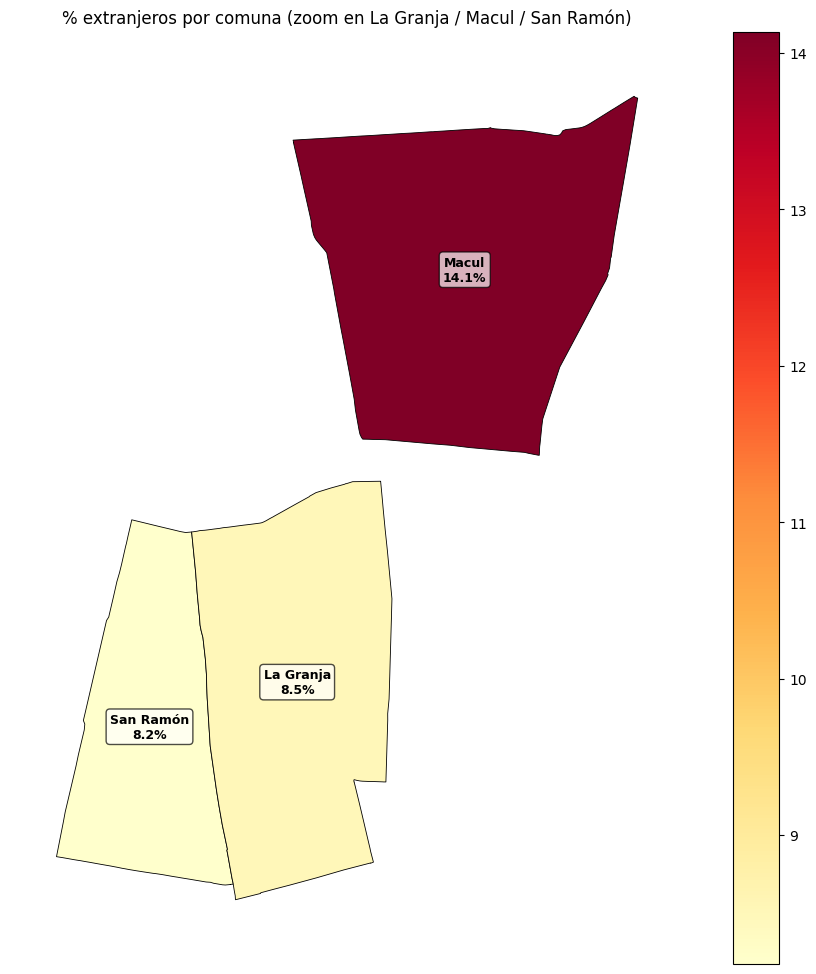

In [39]:
# 3.2 Choropleth % extranjero (haz zoom en las tres comunas)
selected = comunas_merged[comunas_merged["comuna"].isin(MY_COMUNAS)]

if selected.empty: # Si no hay geometría seleccionada, alerta
    raise ValueError("No se encontraron comunas para el mapa 3.2") # verificamos si el DataFrame selected está vacío después de filtrar por las comunas asignadas, y si es así, lanzamos un ValueError con un mensaje que indica que no se encontraron comunas para el mapa 3.2, lo que nos ayuda a identificar rápidamente si hay un problema con los datos o el filtrado antes de intentar crear el mapa

minx, miny, maxx, maxy = selected.total_bounds # calculamos los límites del área que abarca la geometría de las comunas seleccionadas utilizando el método total_bounds, lo que nos da las coordenadas mínimas y máximas en x e y para esa área, y luego calculamos un margen adicional (dx y dy) para agregar un poco de espacio alrededor de las comunas en el mapa

dx = (maxx - minx) * 0.08 # calculamos un margen horizontal (dx) que es el 8% del ancho del área definida por los límites minx y maxx, lo que nos da un espacio adicional para que el mapa no quede demasiado ajustado a las comunas seleccionadas
dy = (maxy - miny) * 0.08 # calculamos un margen vertical (dy) que es el 8% de la altura del área definida por los límites miny y maxy, lo que nos da un espacio adicional para que el mapa no quede demasiado ajustado a las comunas seleccionadas

fig3, ax3 = plt.subplots(1, 1, figsize=(10, 10)) # creamos una figura y un eje para el mapa con un tamaño de 10x10 pulgadas
selected.plot(column="pct_foreign", ax=ax3, legend=True, cmap="YlOrRd", # dibujamos un mapa coroplético utilizando el método plot en el DataFrame selected, especificando la columna pct_foreign para colorear las comunas según el porcentaje de población extranjera, el eje ax3 para colocar el mapa en el eje creado, legend=True para mostrar una leyenda del mapa, cmap="YlOrRd" para usar una paleta de colores que va de amarillo a rojo, y
              missing_kwds={"color": "lightgrey"}, edgecolor="black", linewidth=0.6) # missing_kwds se utiliza para especificar cómo se deben mostrar las comunas que no tienen datos para pct_foreign, en este caso se les asigna un color gris claro, mientras que edgecolor y linewidth se utilizan para dib

# Opcional: top 3 comunas por pct_foreign en el texto
for idx, row in selected.iterrows(): # iteramos sobre las filas del DataFrame selected utilizando iterrows para obtener tanto el índice (idx) como la fila completa (row) de cada comuna seleccionada, lo que nos permite acceder a la geometría y los datos de cada comuna para agregar etiquetas de texto en el mapa
    if row.geometry.centroid.is_empty: # verificamos si el centroide de la geometría de la comuna está vacío utilizando row.geometry.centroid.is_empty, lo que puede ocurrir si la geometría no es válida o no tiene un centroide definido, y si es así, usamos continue para saltar a la siguiente iteración del bucle sin intentar agregar una etiqueta para esa comuna, lo que evita errores al intentar acceder a las coordenadas de un centroide inexistente
        continue # si el centroide está vacío, saltamos a la siguiente iteración del bucle para evitar errores al intentar acceder a las coordenadas de un centroide inexistente
    x, y = row.geometry.centroid.coords[0] # obtenemos las coordenadas del centroide de la geometría de la comuna utilizando row.geometry.centroid.coords[0], lo que nos da una tupla con las coordenadas x e y del centroide, y luego asignamos estas coordenadas a las variables x e y para usarlas como posición para agregar el texto en el mapa
    name = code_to_name.get(int(row["comuna"]), str(row["comuna"])) # obtenemos el nombre de la comuna utilizando el diccionario code_to_name para mapear el código de comuna (convertido a entero) a su nombre correspondiente, y si el código no se encuentra en el diccionario, usamos str(row["comuna"]) para mostrar el código como una cadena de texto, lo que nos da un nombre legible para la comuna que podemos usar en la etiqueta del mapa
    pct = row["pct_foreign"] # obtenemos el porcentaje de población extranjera para esa comuna desde la columna pct_foreign de la fila actual, lo que nos da el valor que queremos mostrar en la etiqueta del mapa junto con el nombre de la comuna
    ax3.text(x, y, f"{name}\n{pct:.1f}%", fontsize=9, fontweight="bold", # agregamos una etiqueta de texto en el mapa utilizando el método text del eje ax3, posicionando el texto en las coordenadas x e y del centroide de la comuna, con un formato que muestra el nombre de la comuna seguido del porcentaje de población extranjera con un decimal, y configurando el tamaño de fuente, el peso de la fuente y opcionalmente el color del texto para que sea legible sobre el fondo del mapa, además de agregar un fondo blanco semitransparente detrás del texto para mejorar la legibilidad
             ha="center", va="center", color="black",
             bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3"))

ax3.set_xlim(minx - dx, maxx + dx) # establecemos los límites del eje x del mapa utilizando set_xlim para que el mapa se enfoque en el área definida por los límites minx y maxx con un margen adicional definido por dx, lo que nos permite hacer un zoom en las comunas seleccionadas sin mostrar áreas innecesarias alrededor
ax3.set_ylim(miny - dy, maxy + dy) # establecemos los límites del eje y del mapa utilizando set_ylim para que el mapa se enfoque en el área definida por los límites miny y maxy con un margen adicional definido por dy, lo que nos permite hacer un zoom en las comunas seleccionadas sin mostrar áreas innecesarias alrededor
ax3.set_title("% extranjeros por comuna (zoom en La Granja / Macul / San Ramón)") # establecemos el título del mapa como "% extranjeros por comuna (zoom en La Granja / Macul / San Ramón)" para indicar claramente qué se está mostrando en el mapa y que se trata de un zoom en las comunas asignadas
ax3.axis("off") # ocultamos los ejes del mapa utilizando axis("off") para que el mapa se vea más limpio y se enfoque en la información geográfica sin distracciones de los ejes
plt.tight_layout()

---
## Part 4: Comuna-Level Summary Table (1 pt)

This is the most important output of Tarea 1.  Build a summary
table at the **comuna level** with the following columns, computed
separately for **Chilean-born** and **foreign-born** where
indicated:

| Column                    | Description                                      |
|:--------------------------|:-------------------------------------------------|
| `codigo_comuna`           | Numeric comuna code                              |
| `nombre_comuna`           | Comuna name                                      |
| `pop_total`               | Total population                                 |
| `pop_chilean`             | Chilean-born population                          |
| `pop_foreign`             | Foreign-born population                          |
| `pct_foreign`             | % foreign-born                                   |
| `median_age_chilean`      | Median age, Chilean-born                         |
| `median_age_foreign`      | Median age, foreign-born                         |
| `mean_schooling_chilean`  | Mean years of schooling (age 25+), Chilean-born  |
| `mean_schooling_foreign`  | Mean years of schooling (age 25+), foreign-born  |
| `emp_rate_chilean`        | Employment rate (age 15-64), Chilean-born        |
| `emp_rate_foreign`        | Employment rate (age 15-64), foreign-born        |
| `dependency_ratio`        | Age dependency ratio (overall)                   |


In [ ]:
# 4. Comuna-Level Summary Table (1 pt)
code_to_name = {13111: "La Granja", 13118: "Macul", 13131: "San Ramón"}

def build_summary(group): # función que toma un grupo de datos (correspondiente a una comuna) y calcula estadísticas resumidas para esa comuna, devolviendo los resultados como una Serie de pandas
    comuna_code = group.name  # groupby('comuna') setea el nombre del grupo
    comuna_name = code_to_name.get(comuna_code, str(comuna_code)) # obtenemos el nombre de la comuna a partir del código utilizando el diccionario code_to_name, y si el código no está en el diccionario, usamos el código como nombre (convertido a string) para evitar errores

    chilean = group[group["p25_lug_nacimiento_rec"] == 1] # filtramos el grupo para quedarnos solo con las filas donde la columna p25_lug_nacimiento_rec tenga el valor 1, lo que corresponde a personas chilenas, y asignamos el resultado a la variable chilean
    foreign = group[group["p25_lug_nacimiento_rec"] == 2] # filtramos el grupo para quedarnos solo con las filas donde la columna p25_lug_nacimiento_rec tenga el valor 2, lo que corresponde a personas extranjeras, y asignamos el resultado a la variable foreign

    stad = { # creamos un diccionario llamado stad para almacenar las estadísticas resumidas de la comuna, comenzando con el código de comuna, el nombre de la comuna, el total de población, la población chilena, la población extranjera, el porcentaje de población extranjera, y las medianas de edad para chilenos y extranjeros
        "codigo_comuna": comuna_code, # almacenamos el código de la comuna en la clave "codigo_comuna" del diccionario stad
        "nombre_comuna": comuna_name, 
        "pop_total": len(group),
        "pop_chilean": len(chilean),
        "pop_foreign": len(foreign),
        "pct_foreign": 100 * len(foreign) / len(group) if len(group) > 0 else 0, # calculamos el porcentaje de población extranjera dividiendo la población extranjera por el total de población y multiplicando por 100, asegurándonos de manejar el caso donde el total de población sea 0 para evitar división por cero
        "median_age_chilean": chilean.loc[chilean["edad"] != -99, "edad"].median(), # calculamos la mediana de edad para la población chilena filtrando primero para quedarnos solo con las filas donde la columna edad no tenga el valor -99 (que indica datos faltantes), y luego aplicando la función median() a la columna edad del DataFrame resultante, almacenando el resultado en la clave "median_age_chilean" del diccionario stad
        "median_age_foreign": foreign.loc[foreign["edad"] != -99, "edad"].median(), # calculamos la mediana de edad para la población extranjera filtrando primero para quedarnos solo con las filas donde la columna edad no tenga el valor -99 (que indica datos faltantes), y luego aplicando la función median() a la columna edad del DataFrame resultante, almacenando el resultado en la clave "median_age_foreign" del diccionario stad
    }

    chilean_25 = chilean[chilean["edad"].between(25, 120) & (chilean["escolaridad"] != -99)] # filtramos el DataFrame chilean para quedarnos solo con las filas donde la columna edad tenga un valor entre 25 y 120 (inclusive) y la columna escolaridad no tenga el valor -99, lo que nos da un DataFrame limpio de personas chilenas de 25 años o más con información válida sobre su nivel de escolaridad, y asignamos el resultado a la variable chilean_25
    foreign_25 = foreign[foreign["edad"].between(25, 120) & (foreign["escolaridad"] != -99)] # filtramos el DataFrame foreign para quedarnos solo con las filas donde la columna edad tenga un valor entre 25 y 120 (inclusive) y la columna escolaridad no tenga el valor -99, lo que nos da un DataFrame limpio de personas extranjeras de 25 años o más con información válida sobre su nivel de escolaridad, y asignamos el resultado a la variable foreign_25
    stad["mean_schooling_chilean"] = chilean_25["escolaridad"].mean() # calculamos la media de años de escolaridad para la población chilena de 25 años o más utilizando la columna escolaridad del DataFrame chilean_25, y almacenamos el resultado en la clave "mean_schooling_chilean" del diccionario stad
    stad["mean_schooling_foreign"] = foreign_25["escolaridad"].mean() # calculamos la media de años de escolaridad para la población extranjera de 25 años o más utilizando la columna escolaridad del DataFrame foreign_25, y almacenamos el resultado en la clave "mean_schooling_foreign" del diccionario stad

    chilean_15_64 = chilean[chilean["edad"].between(15, 64) & (chilean["sit_fuerza_trabajo"] != -99)] # filtramos el DataFrame chilean para quedarnos solo con las filas donde la columna edad tenga un valor entre 15 y 64 (inclusive) y la columna sit_fuerza_trabajo no tenga el valor -99, lo que nos da un DataFrame limpio de personas chilenas en edad laboral con información válida sobre su situación en la fuerza laboral, y asignamos el resultado a la variable chilean_15_64
    foreign_15_64 = foreign[foreign["edad"].between(15, 64) & (foreign["sit_fuerza_trabajo"] != -99)] # filtramos el DataFrame foreign para quedarnos solo con las filas donde la columna edad tenga un valor entre 15 y 64 (inclusive) y la columna sit_fuerza_trabajo no tenga el valor -99, lo que nos da un DataFrame limpio de personas extranjeras en edad laboral con información válida sobre su situación en la fuerza laboral, y asignamos el resultado a la variable foreign_15_64
    stad["emp_rate_chilean"] = chilean_15_64["sit_fuerza_trabajo"].eq(1).mean() # calculamos la tasa de empleo para la población chilena en edad laboral utilizando la columna sit_fuerza_trabajo del DataFrame chilean_15_64, comparando cada valor con 1 (que indica que la persona está empleada) para obtener una serie booleana, y luego calculando la media de esa serie booleana para obtener la proporción de personas empleadas, almacenando el resultado en la clave "emp_rate_chilean" del diccionario stad
    stad["emp_rate_foreign"] = foreign_15_64["sit_fuerza_trabajo"].eq(1).mean() # calculamos la tasa de empleo para la población extranjera en edad laboral utilizando la columna sit_fuerza_trabajo del DataFrame foreign_15_64, comparando cada valor con 1 (que indica que la persona está empleada) para obtener una serie booleana, y luego calculando la media de esa serie booleana para obtener la proporción de personas empleadas, almacenando el resultado en la clave "emp_rate_foreign" del diccionario stad

    aged_0_14 = group[group["edad"].between(0, 14)] # filtramos el grupo para quedarnos solo con las filas donde la columna edad tenga un valor entre 0 y 14 (inclusive), lo que nos da un DataFrame de personas en edad de dependencia infantil, y asignamos el resultado a la variable aged_0_14
    aged_65 = group[group["edad"] >= 65] # filtramos el grupo para quedarnos solo con las filas donde la columna edad tenga un valor mayor o igual a 65, lo que nos da un DataFrame de personas en edad de dependencia por vejez, y asignamos el resultado a la variable aged_65
    aged_15_64 = group[group["edad"].between(15, 64)] # filtramos el grupo para quedarnos solo con las filas donde la columna edad tenga un valor entre 15 y 64 (inclusive), lo que nos da un DataFrame de personas en edad laboral, y asignamos el resultado a la variable aged_15_64
    stad["dependency_ratio"] = (len(aged_0_14) + len(aged_65)) / len(aged_15_64) if len(aged_15_64) > 0 else np.nan # calculamos la tasa de dependencia dividiendo la suma de personas en edad de dependencia infantil (0-14 años) y personas en edad de dependencia por vejez (65 años o más) por el número de personas en edad laboral (15-64 años), asegurándonos de manejar el caso donde el número de personas en edad laboral sea 0 para evitar división por cero, y almacenamos el resultado en la clave "dependency_ratio" del diccionario stad

    return pd.Series(stad) # convertimos el diccionario stad a una Serie de pandas para que pueda ser fácilmente combinada con otros resultados al usar groupby.apply()

from pathlib import Path # importamos la clase Path del módulo pathlib, que proporciona una forma conveniente de trabajar con rutas de archivos y directorios en el sistema de archivos, permitiéndonos crear directorios de manera segura y compatible con diferentes sistemas operativos
Path("output").mkdir(parents=True, exist_ok=True) # creamos un directorio llamado "output" en el sistema de archivos utilizando el método mkdir de la clase Path, con los argumentos parents=True para crear cualquier directorio padre necesario y exist_ok=True para evitar errores si el directorio ya existe, lo que nos asegura que el directorio "output" esté disponible para guardar el archivo CSV resultante sin importar si ya existía o no

summary = df.groupby("comuna").apply(build_summary).reset_index(drop=True) # agrupamos el DataFrame df por la columna comuna y aplicamos la función build_summary a cada grupo de comuna utilizando el método apply, lo que nos da un DataFrame donde cada fila corresponde a una comuna con sus estadísticas resumidas, y luego usamos reset_index(drop=True) para restablecer el índice del DataFrame resultante y eliminar la columna de índice original que se creó al agrupar por comuna, lo que nos da un DataFrame limpio con las estadísticas resumidas para cada comuna
summary.to_csv("output/tarea1_comuna_summary.csv", index=False) # guardamos el DataFrame summary en un archivo CSV llamado "tarea1_comuna_summary.csv" dentro del directorio "output" utilizando el método to_csv, con el argumento index=False para evitar que se guarde la columna de índice en el archivo CSV, lo que nos da un archivo limpio con solo las columnas de datos sin un índice adicional
print(summary)
summary

   codigo_comuna nombre_comuna  pop_total  pop_chilean  pop_foreign  \
0          13111     La Granja     112022       101705         9550   
1          13118         Macul     123800       105336        17497   
2          13131     San Ramón      76002        69248         6214   

   pct_foreign  median_age_chilean  median_age_foreign  \
0     8.525111                39.0                32.0   
1    14.133279                39.0                35.0   
2     8.176101                40.0                32.0   

   mean_schooling_chilean  mean_schooling_foreign  emp_rate_chilean  \
0               10.856734               12.150499          0.593572   
1               13.336334               14.598976          0.691404   
2               10.520867               11.916823          0.603260   

   emp_rate_foreign  dependency_ratio  
0          0.721394          0.498642  
1          0.811891          0.441328  
2          0.738268          0.496692  


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13111,La Granja,112022,101705,9550,8.525111,39.0,32.0,10.856734,12.150499,0.593572,0.721394,0.498642
1,13118,Macul,123800,105336,17497,14.133279,39.0,35.0,13.336334,14.598976,0.691404,0.811891,0.441328
2,13131,San Ramón,76002,69248,6214,8.176101,40.0,32.0,10.520867,11.916823,0.603260,0.738268,0.496692


You will define the `build_summary` function yourself.  Display the
resulting table in your notebook.  Also save it as a CSV file in
your repository (you will need it in Tarea 3).

**Tip**: handle `-99` (missing) values by excluding them from
calculations, not by treating them as valid numbers.


---

## Deliverables

Submit on **Canvas** before class on Thursday, March 26:

1. **PDF export** of your Colab notebook (File > Print > Save as
   PDF, or File > Download > Download .pdf).
2. **Link to your GitHub repository** (the notebook and the
   summary CSV should be committed).

Your notebook must include:

- Markdown cells explaining each step and interpreting results
- All code cells executed with visible output
- The following visualizations:
  - Age pyramid with Chilean/Foreign overlay (Part 1.1)
  - Household size distribution (Part 1.3)
  - Education/employment grouped bar chart (Part 1.4)
  - Top nationalities bar chart (Part 2.2)
  - Migration status stacked bar chart (Part 2.3)
  - Arrival period bar chart (Part 2.4)
  - Two choropleth maps (Part 3)
- The comuna-level summary table (Part 4), both displayed and saved
  as CSV



## Tips and Common Pitfalls

- **Missing values**: the Census uses `-99` to encode missing data.
  Always filter these out before computing means, medians, or rates.
  Do not use `dropna()` blindly; check whether missingness is coded
  as `-99` or as actual `NaN`.
- **Memory**: if your machine struggles with the full national
  tables, filter to your comunas as early as possible (ideally at
  load time using pyarrow filters).
- **Variable dictionary**: keep `diccionario_variables_censo2024.xlsx`
  open while you work.  Many variables are numeric codes that need
  decoding.
- **Consistent nationality grouping**: throughout this assignment,
  use `p25_lug_nacimiento_rec` to split Chilean vs. Foreign.  Use
  `p27_nacionalidad` only when you need detailed nationalities
  (Part 2.2).
- **Age filters**: some indicators only make sense for specific age
  groups (schooling for 25+, employment for 15-64).  Always state
  your filter explicitly.
- **Ecological note**: everything in this assignment is at the
  individual or comuna level within a single dataset (Census).
  Cross-dataset ecological analysis comes in Tarea 3.

---

# Grading Breakdown

| Part                                          | Points |
|:----------------------------------------------|:------:|
| Part 0: Data loading & joins                  |   2    |
| Part 1: Demographic profile                   |   3    |
| Part 2: Migration landscape                   |   3    |
| Part 3: Spatial visualization                 |   1    |
| Part 4: Comuna-level summary table            |   1    |
| **Total**                                     | **10** |

Half of each part's score comes from correct code and output; the
other half comes from clear Markdown explanations and thoughtful
interpretation of your results.

---

Typeset with: `pandoc assignments/Tarea1.md -o assignments/Tarea1.pdf --pdf-engine=pdflatex && evince assignments/Tarea1.pdf &`
